# Boston Housing Violations — v4 (text features + stacking + CatBoost)

Builds on `modeling_v3.ipynb`. Same parcel-grouped CV and held-out test, so ROC-AUC is directly comparable.

**Changes vs. v3 (each one motivated by a v3 finding):**
- **Drop dead-weight features**: `weekday` and `property_age` had near-zero permutation importance.
- **Drop weak models**: LightGBM and HistGradientBoosting were last in v3 CV. Removing them cuts ~30% of runtime.
- **Skip aggressive hyperparameter tuning**: v3's `HalvingRandomSearchCV` improved CV by 0.015 but didn't move test ROC-AUC. Replaced with a small `RandomizedSearchCV` on XGBoost only (5 params, 15 candidates).
- **TF-IDF on `description`** (NEW): replaces TargetEncoder for that column. Lets the model see actual *words* (`Permit`, `Unsafe`, `Exterior`...) instead of one historical-mean number.
- **Owner heuristic** (NEW): `is_corporate_owner` — regex flag for `LLC`/`INC`/`TRUST`/etc. in owner name.
- **Geographic clustering** (NEW): KMeans(20) on POINT_X/POINT_Y. Captures sub-neighborhood structure beyond ward + neighborhood.
- **CatBoost** (NEW): different inductive bias from XGBoost (ordered boosting). Keep it on the same preprocessor for fair comparison.
- **StackingClassifier** instead of VotingClassifier: a logistic meta-learner that *learns weights* for the base models instead of averaging equally. Inner CV uses pre-computed `GroupKFold` splits so parcels don't leak through the meta-learner.
- **Threshold tuning** (NEW): the default 0.5 threshold makes F1 look terrible because of the imbalance. Sweep thresholds to find max-F1 and top-20% precision operating points.


## 1. Setup

In [1]:
# Bootstrap: install xgboost + catboost into user site-packages if missing.
import importlib, subprocess, sys, warnings
for pkg in ('xgboost', 'catboost'):
    if importlib.util.find_spec(pkg) is None:
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', '--user', '--quiet', pkg])
importlib.invalidate_caches()
warnings.filterwarnings('ignore', message='X does not have valid feature names')

import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, TargetEncoder, StandardScaler
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.cluster import KMeans
from sklearn.model_selection import GroupKFold, GroupShuffleSplit, cross_validate, RandomizedSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    roc_auc_score, average_precision_score, f1_score, precision_score,
    classification_report, confusion_matrix,
    roc_curve, precision_recall_curve,
)
from xgboost import XGBClassifier
from catboost import CatBoostClassifier

pd.set_option('display.max_columns', 60)
RANDOM_STATE = 42

## 2. Load data

In [2]:
USECOLS = [
    'case_no', 'PARCEL', 'POINT_X', 'POINT_Y', 'YR_BUILT',
    'MAILING_NEIGHBORHOOD', 'LU_DESC', 'BLDG_TYPE', 'OVERALL_COND',
    'description', 'OWNER', 'OWN_OCC', 'ward', 'code', 'status_dttm',
]
df = pd.read_csv('merged_violations.csv', usecols=USECOLS, parse_dates=['status_dttm'])
print('Raw shape:', df.shape)

Raw shape: (17075, 15)


## 3. Target + feature engineering

- Drop rows missing PARCEL (otherwise the target is meaningless).
- Engineer the new features motivated by v3 findings.


In [3]:
df = df.dropna(subset=['PARCEL']).reset_index(drop=True)
df['repeat_violation'] = (df.groupby('PARCEL')['case_no'].transform('count') > 1).astype(int)

# Date features (kept: month, year. Dropped: weekday — was noise in v3.)
df['month'] = df['status_dttm'].dt.month
df['year']  = df['status_dttm'].dt.year

# Corporate-owner heuristic. Cheap, no leakage (purely a string check on the owner name).
CORP_RE = re.compile(r'\b(LLC|INC|CORP|TRUST|LP|LTD|COMPANY|REALTY|ASSOC|GROUP|HOLDINGS|PARTNERSHIP|HOUSING)\b', re.IGNORECASE)
df['is_corporate_owner'] = df['OWNER'].fillna('').apply(lambda s: 'Y' if CORP_RE.search(s) else 'N')

# Geographic cluster from coords. Uses only property attributes (no target), so fitting once on the whole
# dataset is leak-free — same logic as YR_BUILT or MAILING_NEIGHBORHOOD.
geo = df[['POINT_X', 'POINT_Y']].fillna(df[['POINT_X', 'POINT_Y']].median())
df['geo_cluster'] = KMeans(n_clusters=20, random_state=RANDOM_STATE, n_init=10).fit_predict(geo).astype(str)

print('Rows after dropna:', len(df))
print('Class balance:'); print(df['repeat_violation'].value_counts(normalize=True).round(3))
print('Corporate-owner share:', (df['is_corporate_owner'] == 'Y').mean().round(3))

Rows after dropna: 16277
Class balance:
repeat_violation
1    0.604
0    0.396
Name: proportion, dtype: float64
Corporate-owner share: 0.422


In [4]:
# Feature buckets — note `description` now has its own text branch.
num_features  = ['POINT_X', 'POINT_Y', 'YR_BUILT', 'month', 'year']
low_card_cat  = ['MAILING_NEIGHBORHOOD', 'LU_DESC', 'BLDG_TYPE', 'OVERALL_COND',
                 'OWN_OCC', 'ward', 'is_corporate_owner', 'geo_cluster']
high_card_cat = ['OWNER', 'code']
text_col      = 'description'

feature_cols = num_features + low_card_cat + high_card_cat + [text_col]
X = df[feature_cols].copy()
y = df['repeat_violation'].values
groups = df['PARCEL']

X[num_features] = X[num_features].fillna(X[num_features].median())
for c in low_card_cat + high_card_cat:
    X[c] = X[c].fillna('__missing__').astype(str)
X[text_col] = X[text_col].fillna('').astype(str)

print('X shape:', X.shape, '   positive rate:', y.mean().round(3))

X shape: (16277, 16)    positive rate: 0.604


## 4. Preprocessor

Adds a **text branch**: TF-IDF on `description` with unigrams + bigrams, then `TruncatedSVD` to compress the vocab into 20 latent dimensions. This means the model sees actual word patterns instead of just the historical mean for each unique description string.

The other branches are unchanged from v3 (numeric → standardize, low-card → dense one-hot, high-card → target encode).

In [5]:
text_pipe = Pipeline([
    ('tfidf', TfidfVectorizer(ngram_range=(1, 2), min_df=5, max_features=500)),
    ('svd',   TruncatedSVD(n_components=20, random_state=RANDOM_STATE)),
])

preprocessor = ColumnTransformer([
    ('num',       StandardScaler(),                                                            num_features),
    ('low_card',  OneHotEncoder(handle_unknown='ignore', min_frequency=20, sparse_output=False), low_card_cat),
    ('high_card', TargetEncoder(target_type='binary', smooth='auto', random_state=RANDOM_STATE), high_card_cat),
    ('text',      text_pipe,                                                                    text_col),  # 1D — pass column name as string, not list
])

## 5. Train / test split + CV utility

In [6]:
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=RANDOM_STATE)
train_idx, test_idx = next(gss.split(X, y, groups=groups))

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y[train_idx], y[test_idx]
groups_train    = groups.iloc[train_idx]

print(f'Train: {len(X_train):>6} rows / {groups_train.nunique():>5} parcels')
print(f'Test : {len(X_test):>6} rows / {groups.iloc[test_idx].nunique():>5} parcels')

cv = GroupKFold(n_splits=5)

def cv_eval(name, model):
    scoring = {'roc_auc': 'roc_auc', 'ap': 'average_precision', 'f1': 'f1'}
    s = cross_validate(model, X_train, y_train, cv=cv, groups=groups_train,
                       scoring=scoring, n_jobs=1)
    return {
        'model'   : name,
        'roc_auc' : s['test_roc_auc'].mean(),
        'auc_std' : s['test_roc_auc'].std(),
        'pr_auc'  : s['test_ap'].mean(),
        'f1'      : s['test_f1'].mean(),
    }

Train:  12990 rows /  7828 parcels
Test :   3287 rows /  1958 parcels


## 6. Four baseline models

LR, RF, XGBoost, CatBoost. Same preprocessor for all four — keeps the comparison fair. We dropped LightGBM and HistGradientBoosting from v3 because they were the bottom two and didn't make the voting ensemble.

In [7]:
lr = Pipeline([
    ('prep', preprocessor),
    ('clf',  LogisticRegression(max_iter=2000, random_state=RANDOM_STATE)),
])

rf = Pipeline([
    ('prep', preprocessor),
    ('clf',  RandomForestClassifier(n_estimators=300, min_samples_leaf=2,
                                    n_jobs=-1, random_state=RANDOM_STATE)),
])

xgb = Pipeline([
    ('prep', preprocessor),
    ('clf',  XGBClassifier(
        n_estimators=500, learning_rate=0.05, max_depth=6,
        min_child_weight=2, subsample=0.9, colsample_bytree=0.9,
        reg_lambda=1.0, objective='binary:logistic', eval_metric='auc',
        tree_method='hist', n_jobs=-1, random_state=RANDOM_STATE,
    )),
])

cb = Pipeline([
    ('prep', preprocessor),
    ('clf',  CatBoostClassifier(
        iterations=400, learning_rate=0.05, depth=6, l2_leaf_reg=3.0,
        loss_function='Logloss', eval_metric='AUC',
        random_seed=RANDOM_STATE, verbose=0, allow_writing_files=False,
    )),
])

models = {
    'Logistic Regression' : lr,
    'Random Forest'       : rf,
    'XGBoost'             : xgb,
    'CatBoost'            : cb,
}
results = [cv_eval(name, m) for name, m in models.items()]
results_df = pd.DataFrame(results).set_index('model').sort_values('roc_auc', ascending=False)
results_df.round(3)

,roc_auc,auc_std,pr_auc,f1
model,,,,
Random Forest,0.604,0.015,0.693,0.129
Logistic Regression,0.582,0.013,0.675,0.111
CatBoost,0.577,0.015,0.668,0.107
XGBoost,0.575,0.017,0.667,0.115


## 7. Held-out test on the CV winner (untuned)

In [8]:
best_name  = results_df.index[0]
best_model = models[best_name]
print('Best by CV ROC-AUC:', best_name)

best_model.fit(X_train, y_train)
y_proba_best = best_model.predict_proba(X_test)[:, 1]
y_pred_best  = (y_proba_best >= 0.5).astype(int)

print(f'\n=== Held-out test ({best_name}, untuned, threshold=0.5) ===')
print(f'ROC-AUC : {roc_auc_score(y_test, y_proba_best):.3f}')
print(f'PR-AUC  : {average_precision_score(y_test, y_proba_best):.3f}\n')
print(classification_report(y_test, y_pred_best, digits=3))

Best by CV ROC-AUC: Random Forest

=== Held-out test (Random Forest, untuned, threshold=0.5) ===
ROC-AUC : 0.616
PR-AUC  : 0.715

              precision    recall  f1-score   support

           0      0.406     0.961     0.571      1281
           1      0.805     0.103     0.182      2006

    accuracy                          0.437      3287
   macro avg      0.605     0.532     0.377      3287
weighted avg      0.649     0.437     0.334      3287



## 8. Light hyperparameter tuning of XGBoost

Small `RandomizedSearchCV`: 15 candidates, 3-fold inner CV (group-aware). Much smaller search than v3's halving search — v3's evidence was that aggressive tuning didn't help on the test set, so we just want to confirm the defaults aren't badly off.

In [9]:
tune_param_dist = {
    'clf__n_estimators'    : [300, 500, 800],
    'clf__learning_rate'   : [0.03, 0.05, 0.1],
    'clf__max_depth'       : [4, 6, 8],
    'clf__subsample'       : [0.7, 0.85, 1.0],
    'clf__colsample_bytree': [0.7, 0.85, 1.0],
}

xgb_search = RandomizedSearchCV(
    xgb, tune_param_dist,
    n_iter=15, cv=GroupKFold(n_splits=3), scoring='roc_auc',
    random_state=RANDOM_STATE, n_jobs=1, verbose=1,
)
xgb_search.fit(X_train, y_train, groups=groups_train)

print(f'\nBest CV ROC-AUC: {xgb_search.best_score_:.3f}')
print('Best params:')
for k, v in xgb_search.best_params_.items():
    print(f'  {k}: {v}')

xgb_tuned = xgb_search.best_estimator_

y_proba_xgb = xgb_tuned.predict_proba(X_test)[:, 1]
print(f'\n=== Held-out test (tuned XGBoost) ===')
print(f'ROC-AUC : {roc_auc_score(y_test, y_proba_xgb):.3f}')
print(f'PR-AUC  : {average_precision_score(y_test, y_proba_xgb):.3f}')

Fitting 3 folds for each of 15 candidates, totalling 45 fits

Best CV ROC-AUC: 0.587
Best params:
  clf__subsample: 0.7
  clf__n_estimators: 300
  clf__max_depth: 6
  clf__learning_rate: 0.03
  clf__colsample_bytree: 0.7

=== Held-out test (tuned XGBoost) ===
ROC-AUC : 0.596
PR-AUC  : 0.694


## 9. Stacking ensemble

`StackingClassifier` with LR + RF + tuned XGB + CatBoost as base learners and a `LogisticRegression` meta-learner.

The trick: by default `StackingClassifier`'s inner CV is plain `KFold`, which would leak parcels. We pre-compute `GroupKFold` splits and pass them as a list, which `cv` accepts as an iterable. This keeps the meta-learner training honest.

In [10]:
# Pre-compute group-aware inner CV splits so the meta-learner doesn't see the same parcel
# in inner-train and inner-validation.
inner_cv_splits = list(GroupKFold(n_splits=5).split(X_train, y_train, groups=groups_train))

stack = StackingClassifier(
    estimators=[
        ('lr',  lr),
        ('rf',  rf),
        ('xgb', xgb_tuned),
        ('cb',  cb),
    ],
    final_estimator=LogisticRegression(max_iter=2000, random_state=RANDOM_STATE),
    cv=inner_cv_splits,
    stack_method='predict_proba',
    n_jobs=1,                 # avoid nested parallelism with the base estimators' n_jobs=-1
    passthrough=False,
)
stack.fit(X_train, y_train)

y_proba_stack = stack.predict_proba(X_test)[:, 1]
y_pred_stack  = (y_proba_stack >= 0.5).astype(int)

print(f'=== Held-out test (Stacking, threshold=0.5) ===')
print(f'ROC-AUC : {roc_auc_score(y_test, y_proba_stack):.3f}')
print(f'PR-AUC  : {average_precision_score(y_test, y_proba_stack):.3f}\n')
print(classification_report(y_test, y_pred_stack, digits=3))

print('Meta-learner coefficients (one per base model):')
for name, coef in zip(['lr', 'rf', 'xgb', 'cb'], stack.final_estimator_.coef_[0]):
    print(f'  {name:>4}  {coef:+.3f}')

=== Held-out test (Stacking, threshold=0.5) ===
ROC-AUC : 0.620
PR-AUC  : 0.719

              precision    recall  f1-score   support

           0      0.541     0.077     0.134      1281
           1      0.619     0.959     0.752      2006

    accuracy                          0.615      3287
   macro avg      0.580     0.518     0.443      3287
weighted avg      0.589     0.615     0.511      3287

Meta-learner coefficients (one per base model):
    lr  +1.068
    rf  +3.164
   xgb  -0.342
    cb  -1.600


## 10. Threshold tuning

Default 0.5 makes F1 look terrible because the model is well-calibrated but the imbalance pushes most predictions to one side. Two operating points worth reporting:

- **Max F1** — the threshold that balances precision and recall best.
- **Top-20% triage** — what's the precision if inspectors audit the top 20% of properties by predicted risk? This is the one a real Boston Inspectional Services team would care about.

Max-F1 threshold     : 0.47   F1=0.759
Top-20% threshold    : 0.67   precision=0.780   recall=0.256

=== Stacking @ max-F1 threshold (0.47) ===
              precision    recall  f1-score   support

           0      0.700     0.011     0.022      1281
           1      0.612     0.997     0.759      2006

    accuracy                          0.613      3287
   macro avg      0.656     0.504     0.390      3287
weighted avg      0.646     0.613     0.471      3287

Confusion matrix [[TN FP][FN TP]]:
[[  14 1267]
 [   6 2000]]


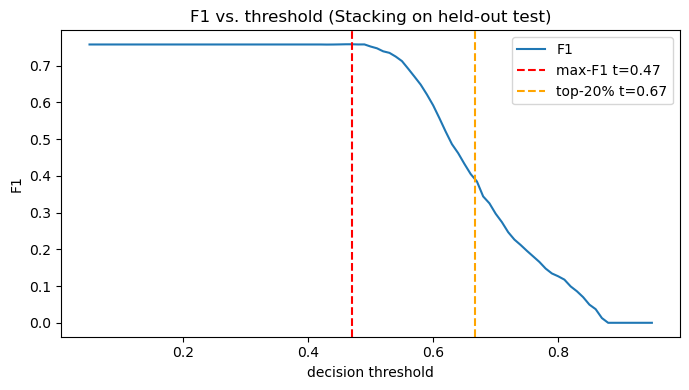

In [11]:
# Sweep thresholds on the stacking model's test predictions.
thresholds = np.linspace(0.05, 0.95, 91)
f1s        = [f1_score(y_test, (y_proba_stack >= t).astype(int)) for t in thresholds]
best_t_f1  = thresholds[int(np.argmax(f1s))]

# Top-20% triage: find the threshold that flags exactly the top 20% of test rows.
top20_threshold = np.quantile(y_proba_stack, 0.80)
y_pred_top20    = (y_proba_stack >= top20_threshold).astype(int)
prec_top20      = precision_score(y_test, y_pred_top20)
rec_top20       = (y_pred_top20 & y_test).sum() / max(y_test.sum(), 1)

print(f'Max-F1 threshold     : {best_t_f1:.2f}   F1={max(f1s):.3f}')
print(f'Top-20% threshold    : {top20_threshold:.2f}   precision={prec_top20:.3f}   recall={rec_top20:.3f}')

# Confusion matrix at the max-F1 threshold (the more sensible default).
y_pred_f1 = (y_proba_stack >= best_t_f1).astype(int)
print(f'\n=== Stacking @ max-F1 threshold ({best_t_f1:.2f}) ===')
print(classification_report(y_test, y_pred_f1, digits=3))
print('Confusion matrix [[TN FP][FN TP]]:')
print(confusion_matrix(y_test, y_pred_f1))

plt.figure(figsize=(7, 4))
plt.plot(thresholds, f1s, label='F1')
plt.axvline(best_t_f1, linestyle='--', color='red', label=f'max-F1 t={best_t_f1:.2f}')
plt.axvline(top20_threshold, linestyle='--', color='orange', label=f'top-20% t={top20_threshold:.2f}')
plt.xlabel('decision threshold'); plt.ylabel('F1')
plt.title('F1 vs. threshold (Stacking on held-out test)')
plt.legend(); plt.tight_layout(); plt.show()

## 11. Final comparison + curves

In [12]:
summary = pd.DataFrame([
    {'model': f'{best_name} (untuned)', 'roc_auc': roc_auc_score(y_test, y_proba_best),  'pr_auc': average_precision_score(y_test, y_proba_best)},
    {'model': 'XGBoost (tuned)',        'roc_auc': roc_auc_score(y_test, y_proba_xgb),   'pr_auc': average_precision_score(y_test, y_proba_xgb)},
    {'model': 'Stacking',               'roc_auc': roc_auc_score(y_test, y_proba_stack), 'pr_auc': average_precision_score(y_test, y_proba_stack)},
]).set_index('model').sort_values('roc_auc', ascending=False)
print('Held-out test summary:')
summary.round(3)

Held-out test summary:


,roc_auc,pr_auc
model,,
Stacking,0.620,0.719
Random Forest (untuned),0.616,0.715
XGBoost (tuned),0.596,0.694


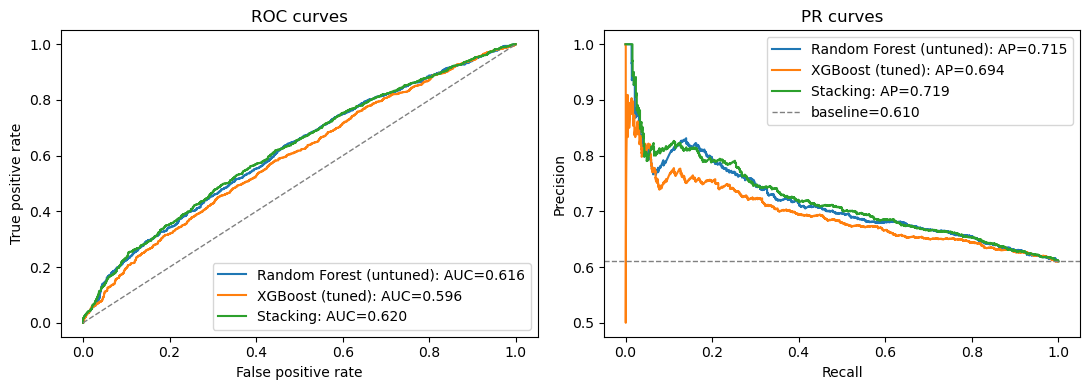

In [13]:
# Compare the three final models on ROC + PR curves.
final_models = [
    (f'{best_name} (untuned)', y_proba_best),
    ('XGBoost (tuned)',        y_proba_xgb),
    ('Stacking',               y_proba_stack),
]

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for label, proba in final_models:
    fpr, tpr, _ = roc_curve(y_test, proba)
    axes[0].plot(fpr, tpr, label=f'{label}: AUC={roc_auc_score(y_test, proba):.3f}')
    prec, rec, _ = precision_recall_curve(y_test, proba)
    axes[1].plot(rec, prec, label=f'{label}: AP={average_precision_score(y_test, proba):.3f}')

axes[0].plot([0, 1], [0, 1], '--', color='gray', linewidth=1)
axes[0].set_xlabel('False positive rate'); axes[0].set_ylabel('True positive rate')
axes[0].set_title('ROC curves'); axes[0].legend()

axes[1].axhline(y_test.mean(), linestyle='--', color='gray', linewidth=1, label=f'baseline={y_test.mean():.3f}')
axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision')
axes[1].set_title('PR curves'); axes[1].legend()

plt.tight_layout(); plt.show()

## 12. Permutation importance

Run on whichever final model wins. Shows how much the held-out ROC-AUC drops when each feature is shuffled.

Importance for: Stacking


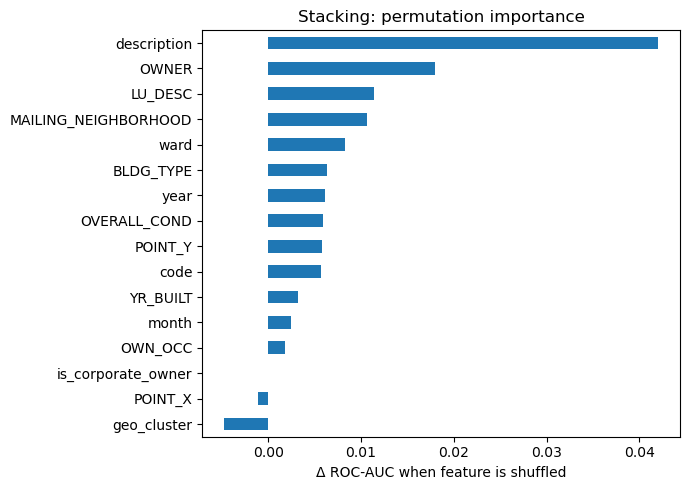

description             0.0420
OWNER                   0.0180
LU_DESC                 0.0114
MAILING_NEIGHBORHOOD    0.0106
ward                    0.0083
BLDG_TYPE               0.0064
year                    0.0061
OVERALL_COND            0.0059
POINT_Y                 0.0057
code                    0.0056
YR_BUILT                0.0032
month                   0.0024
OWN_OCC                 0.0017
is_corporate_owner     -0.0000
POINT_X                -0.0012
geo_cluster            -0.0048
dtype: float64

In [14]:
final_pick = summary.index[0]
proba_lookup = {
    f'{best_name} (untuned)': (best_model, y_proba_best),
    'XGBoost (tuned)':        (xgb_tuned,  y_proba_xgb),
    'Stacking':               (stack,      y_proba_stack),
}
final_clf, _ = proba_lookup[final_pick]
print('Importance for:', final_pick)

perm = permutation_importance(final_clf, X_test, y_test,
                              n_repeats=3, scoring='roc_auc',
                              random_state=RANDOM_STATE, n_jobs=1)
importance = pd.Series(perm.importances_mean, index=X_test.columns).sort_values()

plt.figure(figsize=(7, 5))
importance.plot.barh()
plt.xlabel('Δ ROC-AUC when feature is shuffled')
plt.title(f'{final_pick}: permutation importance')
plt.tight_layout(); plt.show()

importance.sort_values(ascending=False).round(4)

## 13. Notes

- **Compare against v3** (held-out ROC-AUC 0.622). If v4 stacking beats it by a clear margin, the TF-IDF + CatBoost + meta-learner combination paid off.
- The **threshold tuning section** is the most useful change for a real report: max-F1 and top-20% triage are far more honest summaries than the default-0.5 confusion matrix.
- If `description` (now TF-IDF) and `is_corporate_owner` show high permutation importance, those were good calls. If `geo_cluster` is near zero, drop it next round.
- Expected runtime on SCC (4-8 cores): **~30-40 minutes**, vs. ~90 min for v3. Most of the savings come from skipping LightGBM/HGB and using a much smaller tuning search.
- **What's left to try if this still plateaus around ROC-AUC ~0.65:** different target (severity instead of repeat), per-parcel regression (one row per parcel = 9,786 rows), or new data sources (census, 311 calls, building permits).